<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 79 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Chi-Square Tests 🧮</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">When the data are counts in categories, the chi-square test compares what you observed to what you would expect. We build the goodness-of-fit test, the test of independence, and the Cramer's V effect size, then ask whether support-channel choice depends on region.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(79)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · OBSERVED vs EXPECTED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The one idea behind every chi-square test</div>
<div style="color:#4a5578;margin-top:6px">Chi-square tests compare the COUNTS you observed to the counts you would EXPECT under a null hypothesis. The statistic sums (O - E)^2 / E across cells: small when observed matches expected, large when they diverge.</div>
</div>

In [2]:
observed = np.array([22, 17, 20, 13, 18, 10])   # rolls of a die, 100 throws
expected = np.full(6, observed.sum()/6)            # fair die: equal expected counts
chi2 = (((observed-expected)**2)/expected).sum()
print("observed:", observed, " expected:", expected)
print(f"chi-square statistic = sum((O-E)^2/E) = {chi2:.3f}")
print(f"scipy goodness-of-fit: chi2={stats.chisquare(observed,expected).statistic:.3f}, p={stats.chisquare(observed,expected).pvalue:.4f}")

observed: [22 17 20 13 18 10]  expected: [16.66666667 16.66666667 16.66666667 16.66666667 16.66666667 16.66666667]
chi-square statistic = sum((O-E)^2/E) = 5.960
scipy goodness-of-fit: chi2=5.960, p=0.3101


Every chi-square test is this comparison. The contribution (O&#8722;E)&#178;/E is small where the data behave as expected and large where they surprise us; summing across cells gives a single measure of total discrepancy that follows a chi-square distribution under H0.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · GOODNESS-OF-FIT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do the counts match a claimed distribution?</div>
<div style="color:#4a5578;margin-top:6px">The goodness-of-fit test checks whether one categorical variable follows a hypothesized split. Degrees of freedom = (number of categories - 1). Condition: every expected count should be at least ~5 for the chi-square approximation to hold.</div>
</div>

In [3]:
# claim: customers split 40/30/20/10 across four tiers; observe 900
obs = np.array([330, 290, 180, 100]); claim = np.array([0.40,0.30,0.20,0.10])
exp = claim*obs.sum()
res = stats.chisquare(obs, exp)
print(f"observed {obs},  expected {exp}")
print(f"df = {len(obs)-1}, chi2 = {res.statistic:.2f}, p = {res.pvalue:.4f}")
print("min expected count =", exp.min(), "(>= 5, approximation OK)")
print('-> reject H0: the split differs from 40/30/20/10' if res.pvalue<0.05 else '-> consistent with the claim')

observed [330 290 180 100],  expected [360. 270. 180.  90.]
df = 3, chi2 = 5.09, p = 0.1651
min expected count = 90.0 (>= 5, approximation OK)
-> consistent with the claim


A significant goodness-of-fit result means the observed proportions depart from the hypothesized ones by more than chance. It is the categorical analog of a one-sample test, comparing a whole distribution of counts to a benchmark rather than a single mean to a value.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · TEST OF INDEPENDENCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Are two categorical variables related?</div>
<div style="color:#4a5578;margin-top:6px">Given a contingency table (rows = one variable, columns = another), the test of independence asks whether the two are associated. Expected counts assume independence: E = row_total * col_total / grand_total. df = (rows-1)(cols-1). Cramer's V rescales chi-square to an effect size in [0,1].</div>
</div>

In [4]:
table = np.array([[90, 60, 50],[40, 80, 70]])   # 2 groups x 3 preferences
chi2, p, dof, expected = stats.chi2_contingency(table)
n = table.sum(); V = np.sqrt(chi2/(n*(min(table.shape)-1)))
print("expected counts under independence:\n", np.round(expected,1))
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer\u2019s V={V:.3f}")
print('-> reject H0: the variables are associated' if p<0.05 else '-> independent')

expected counts under independence:
 [[66.7 71.8 61.5]
 [63.3 68.2 58.5]]
chi2=25.18, dof=2, p=0.0000, Cramer’s V=0.254
-> reject H0: the variables are associated


The test of independence is the categorical cousin of correlation. A significant chi-square says the row and column variables move together; <strong>Cramer&#39;s V</strong> then says how strongly (0 = no association, 1 = perfect), the essential companion to the p-value, since with enough data even a trivial association is significant.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · SUPPORT CHANNEL BY REGION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two chi-square questions on one dataset</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A company logs each customer&#39;s region and preferred support channel (`ch79_customer_channel.xlsx`). We ask two things: are the four channels used equally often (goodness-of-fit), and does channel preference depend on region (test of independence)?

In [5]:
try:    d = pd.read_excel("../../data/ch79_customer_channel.xlsx", sheet_name="Customers")
except FileNotFoundError: d = pd.read_excel(BASE+"ch79_customer_channel.xlsx", sheet_name="Customers")
# EXPLORE FIRST: size, missing, and the category counts
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print("region:", d.region.value_counts().to_dict())
print("channel:", d.preferred_channel.value_counts().to_dict())
order=["Email","Phone","Chat","App"]
obs = d.preferred_channel.value_counts().reindex(order).values
exp = np.full(4, obs.sum()/4)
gof = stats.chisquare(obs, exp)
print("channel counts:", dict(zip(order,obs)))
print(f"[GOODNESS-OF-FIT vs 25% each] df=3, chi2={gof.statistic:.2f}, p={gof.pvalue:.4f}")
print('-> reject: channels are NOT used equally' if gof.pvalue<0.05 else '-> equal usage plausible')

shape: (900, 4) | missing: 0
region: {'North': 276, 'East': 235, 'South': 213, 'West': 176}
channel: {'Email': 267, 'Chat': 231, 'Phone': 209, 'App': 193}
channel counts: {'Email': np.int64(267), 'Phone': np.int64(209), 'Chat': np.int64(231), 'App': np.int64(193)}
[GOODNESS-OF-FIT vs 25% each] df=3, chi2=13.69, p=0.0034
-> reject: channels are NOT used equally


contingency table (region x channel):
preferred_channel  App  Chat  Email  Phone
region                                    
East                57    78     70     30
North               46    68    105     57
South               29    46     53     85
West                61    39     39     37

[INDEPENDENCE] dof=9, chi2=81.00, p=1.02e-13, Cramer’s V=0.173
-> reject H0: channel preference DEPENDS on region


/var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/ipykernel_72508/3884020231.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  (ct.div(ct.sum(1),axis=0)).plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=0.7)


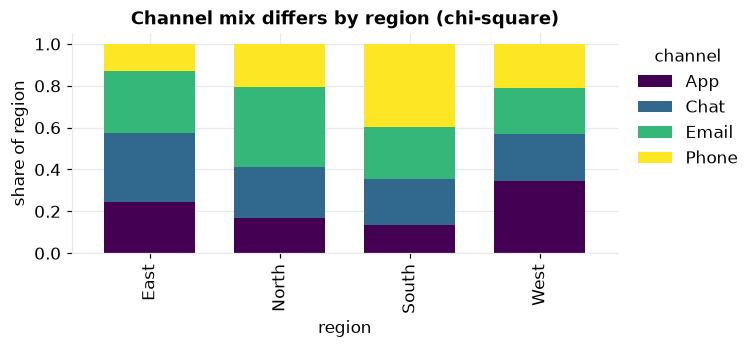

In [6]:
ct = pd.crosstab(d.region, d.preferred_channel)
chi2, p, dof, expected = stats.chi2_contingency(ct)
V = association(ct.values, method="cramer")   # scipy gives Cramer's V directly
print("contingency table (region x channel):"); print(ct)
print(f"\n[INDEPENDENCE] dof={dof}, chi2={chi2:.2f}, p={p:.2e}, Cramer\u2019s V={V:.3f}")
print('-> reject H0: channel preference DEPENDS on region' if p<0.05 else '-> independent')
fig,ax=plt.subplots(figsize=(7,3.3))
(ct.div(ct.sum(1),axis=0)).plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=0.7)
ax.set_ylabel("share of region"); ax.set_title("Channel mix differs by region (chi-square)")
ax.legend(title="channel", bbox_to_anchor=(1.01,1)); plt.tight_layout(); plt.show()

Both tests are significant. The four channels are <em>not</em> used equally (goodness-of-fit &#967;&#178; &#8776; 13.7, p &#8776; 0.003), and channel preference clearly <strong>depends on region</strong> (independence &#967;&#178; &#8776; 81, p &#8776; 10&#8315;&#185;&#179;). But Cramer&#39;s V &#8776; 0.17 says the association, while real, is <em>modest</em>, region nudges the channel mix rather than dictating it. Reporting V alongside the tiny p-value keeps the finding honest.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Chi-square tests</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Chi-square tests compare observed counts to those expected under a null: sum (O&#8722;E)&#178;/E. Goodness-of-fit checks one variable against a claimed split (df = categories &#8722; 1); the test of independence checks whether two categorical variables are associated (df = (r&#8722;1)(c&#8722;1)), with Cramer&#39;s V as the effect size. Keep expected counts &#8805; ~5. On real data, support channels are used unequally (p &#8776; 0.003) and depend on region (p &#8776; 10&#8315;&#185;&#179;, V &#8776; 0.17, a modest link). Next: nonparametric tests for when distributional assumptions fail.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>